In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

import json, pickle
train_path = "/home/andrew/cafa5_team/data/"
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)
with open(f"{train_path}/cafa_dataset/prot_ids.json", "r") as f:
    prot_ids = json.load(f)
with open(f"{train_path}/cafa_dataset/rev_annot.pkl", "rb") as f:
    labels = pickle.load(f)
labels[:, go_terms.index('GO:0035615')].sum()

81

In [2]:
from go_ml.data_utils import *
from go_ml.train_utils import cls_seq_encode
train_path = "/home/andrew/GO_interp/data/elm"
prot_sequences, seq_ids = load_protein_sequences(f"{train_path}/lig_elm_instances.fasta")
prot_sequences = [seq.upper() for seq in prot_sequences]

f_ind = [i for i in range(len(prot_sequences)) if len(prot_sequences[i]) <= 800]
prot_sequences = [prot_sequences[ind] for ind in f_ind]
seq_ids = [seq_ids[ind] for ind in f_ind]

In [3]:
import os
logit_dict = {}
for fp in os.listdir('lip_mutation_scan'):
    logit_dict[fp.split('.')[0]] = torch.load(f'lip_mutation_scan/{fp}')
pid_to_seq = {pid:seq for pid, seq in zip(seq_ids, prot_sequences)}
seqlen_to_eval = {eval_logits.shape[0]:eval_logits for eval_logits in logit_dict.values()}
pid_to_eval = {pid: seqlen_to_eval[len(pid_to_seq[pid])] for pid in seq_ids}
logit_dict = pid_to_eval

In [8]:
prot_dict = {seq_id: prot_seq for seq_id, prot_seq in zip(seq_ids, prot_sequences)}
len(prot_dict[seq_ids[17]]), logit_dict[seq_ids[17]].shape

(338, torch.Size([338, 20, 29185]))

In [5]:
import regex as re
prot_seq = prot_sequences[0]
print([x.span() for x in re.finditer('NPF', prot_seq)])

def regex_mask(seq, motif):
    # print(seq, motif)
    arr = np.zeros(len(seq))
    for match in re.finditer(motif, seq):
        si, ei = match.span()
        arr[si:ei] = 1
    return arr

[(346, 349), (490, 493)]


In [74]:
#Related terms for ELM-lip
# rel_terms = ['GO:0008021', 'GO:0035615', 'GO:0048489', 'GO:0099504', 'GO:1900242', go_terms[47], go_terms[51]]
rel_terms = ['GO:0008021']

import regex as re
def plot_eval_mat(prot_seq, eval_mat, motif='NPF'):
    rm = regex_mask(prot_seq, motif)
    fig, ax = plt.subplots(1,1, figsize=(9,3))
    for i, term in enumerate(rel_terms):
        go_ind = go_terms.index(term)
        p = torch.softmax(torch.FloatTensor(eval_mat[:, :, go_ind]), dim=-1)
        e_score = (p*torch.log(p)).sum(dim=-1)
        ax.plot((e_score + 3.0)*5, label='Var-Score')
    ax.plot(rm*0.1)
    return fig

Q05785


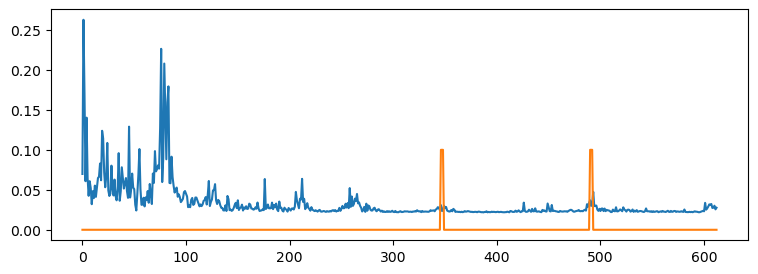

In [119]:
ind = 0
print(seq_ids[ind])
fig = plot_eval_mat(prot_sequences[ind], logit_dict[seq_ids[ind]])
fig.show()

In [52]:
from go_ml.train_utils import get_elm_df
elm_df = get_elm_df()

In [ ]:
elm_entry = elm_df.iloc[29]
prot_seq = elm_entry.Sequence
# prot_seq = prot_sequences[11]
# print(len(prot_seq), seq_ids[11])
print(len(prot_seq), elm_entry.Primary_Acc)
print(elm_entry)

693 Q9BLG6


In [6]:
import transformers
tokenizer = transformers.AutoTokenizer.from_pretrained('facebook/esm2_t6_8M_UR50D')
from go_ml.go_utils import godag, go2parents_isa, get_ancestors

aa_str = 'LAGVSERTIDPKQNFYMHWC'
aa_ind = [tokenizer.get_vocab()[c] for c in aa_str]

import torch
device = torch.device('cuda:0')
from go_ml.models.bert_finetune import BERTFinetune
checkpoint_dir = "/home/andrew/GO_interp/checkpoints"
model = BERTFinetune.load_from_checkpoint(f"{checkpoint_dir}/esm_finetune-v1.ckpt", map_location=device)
model.eval()
print('model loaded')

../go-basic.obo: fmt(1.2) rel(2024-04-24) 45,667 Terms


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model loaded


In [13]:
from tqdm.notebook import tqdm
eval_ind = list(range(1, 1+len(prot_seq)))
aa_str = 'LAGVSERTIDPKQNFYMHWC'
aa_ind = [tokenizer.get_vocab()[c] for c in aa_str]
eval_dict = {}
seq_data = cls_seq_encode(prot_seq.upper(), tokenizer)
with torch.no_grad():
    aa_ind = torch.tensor(aa_ind, device=device)
    seq_ind, mask =  torch.tensor(seq_data['seq_ind']).to(device), torch.BoolTensor(seq_data['mask']).to(device)
    seq_ind = seq_ind[:, :len(prot_seq) + 2]
    mask = mask[:, :len(prot_seq) + 2]
    base_batch_seq = torch.tile(seq_ind, (aa_ind.shape[0], 1))
    batch_mask = torch.tile(mask, (aa_ind.shape[0], 1))
    for res_ind in tqdm(eval_ind):
        batch_seq = base_batch_seq.clone()
        batch_seq[:, res_ind] = aa_ind
        logits = model.forward(batch_seq, batch_mask)
        eval_dict[res_ind] = logits.cpu().numpy()
eval_mat = np.stack([eval_dict[i] for i in range(1, len(eval_dict)+1)])
# pid_eval_dict[prot_id] = eval_mat

  0%|          | 0/693 [00:00<?, ?it/s]

In [16]:
print(elm_entry)

Accession                                               ELMI001091
ELMType                                                        CLV
ELMIdentifier                                        CLV_MEL_PAP_1
ProteinName                                           Q9BLG6_BOMMO
Primary_Acc                                                 Q9BLG6
Accessions                                                  Q9BLG6
Start                                                           48
End                                                             54
References                                                 7644494
Methods                                          edman degradation
InstanceLogic                                        true positive
PDB                                                            NaN
Organism                                               Bombyx mori
Sequence         MADVFESLELLFDRPNEPLITPKGENNSVFQLTEQFLTEDYANNGI...
Regex                                            [ILV]..R[VF][

[]


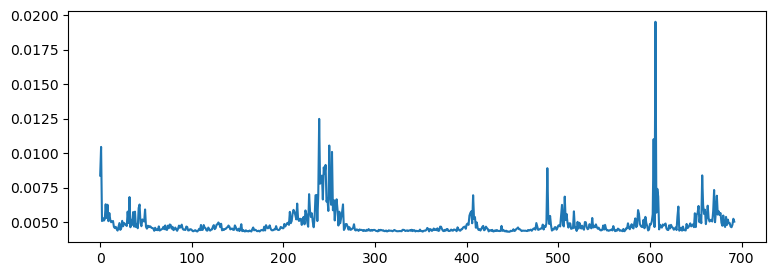

In [19]:
#Related terms for ELM 29
rel_terms = ['GO:0006582']
import regex as re
print(list(re.finditer('NPF', prot_seq)))
fig, ax = plt.subplots(1,1, figsize=(9,3))
for i, term in enumerate(rel_terms):
    go_ind = go_terms.index(term)
    p = torch.softmax(torch.FloatTensor(eval_mat[:, :, go_ind]), dim=-1)
    e_score = (p*torch.log(p)).sum(dim=-1)
    ax.plot(e_score+i*0.05+3.0, label='Var-Score')
plt.show()

[]


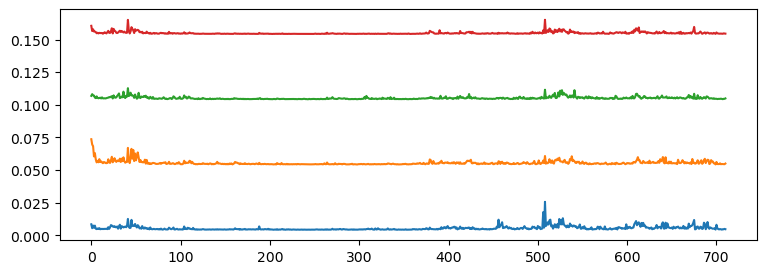

In [ ]:
#Related terms for ELM 11
rel_terms = ['GO:0043508', 'GO:2001243', 'GO:0046330', 'GO:0008432']
import regex as re
print(list(re.finditer('NPF', prot_seq)))
fig, ax = plt.subplots(1,1, figsize=(9,3))
for i, term in enumerate(rel_terms):
    go_ind = go_terms.index(term)
    p = torch.softmax(torch.FloatTensor(eval_mat[:, :, go_ind]), dim=-1)
    e_score = (p*torch.log(p)).sum(dim=-1)
    ax.plot(e_score+i*0.05+3.0, label='Var-Score')

[<regex.Match object; span=(346, 349), match='NPF'>, <regex.Match object; span=(490, 493), match='NPF'>]


NameError: name 'eval_mat' is not defined

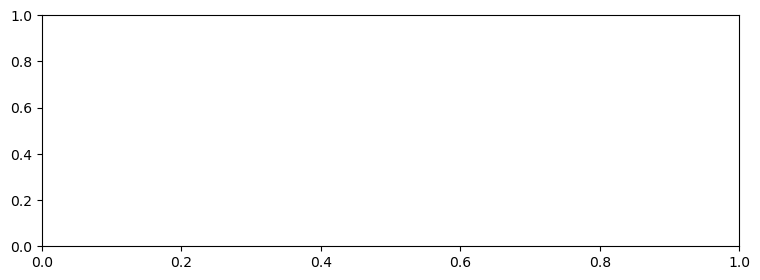

In [53]:
#Related terms for ELM-lip
rel_terms = ['GO:0008021', 'GO:0035615', 'GO:0048489', 'GO:0099504', 'GO:1900242']
import regex as re
print(list(re.finditer('NPF', prot_seq)))
fig, ax = plt.subplots(1,1, figsize=(9,3))
for i, term in enumerate(rel_terms):
    go_ind = go_terms.index(term)
    p = torch.softmax(torch.FloatTensor(eval_mat[:, :, go_ind]), dim=-1)
    e_score = (p*torch.log(p)).sum(dim=-1)
    ax.plot(e_score+i*0.05+3.0, label='Var-Score')

[<regex.Match object; span=(267, 270), match='NPF'>, <regex.Match object; span=(538, 541), match='NPF'>]


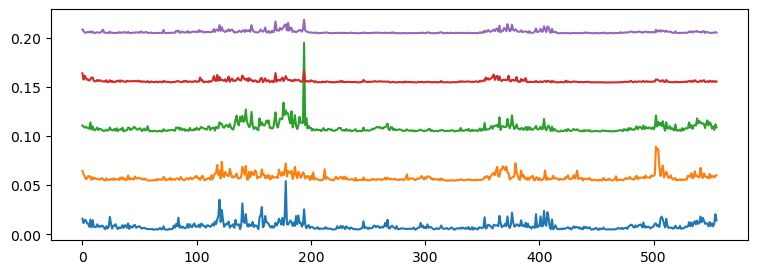

In [96]:
import regex as re
print(list(re.finditer('NPF', prot_seq)))
fig, ax = plt.subplots(1,1, figsize=(9,3))
for i, term in enumerate(rel_terms):
    go_ind = go_terms.index(term)
    p = torch.softmax(torch.FloatTensor(eval_mat[:, :, go_ind]), dim=-1)
    e_score = (p*torch.log(p)).sum(dim=-1)
    ax.plot(e_score+i*0.05+3.0, label='Var-Score')
# ax.plot(-res_entropy_imp+2.8)

[<regex.Match object; span=(267, 270), match='NPF'>, <regex.Match object; span=(538, 541), match='NPF'>]


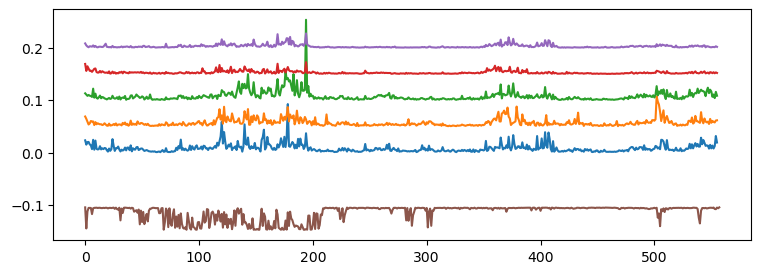

In [ ]:
import regex as re
print(list(re.finditer('NPF', prot_seq)))
fig, ax = plt.subplots(1,1, figsize=(9,3))
for i, term in enumerate(rel_terms):
    go_ind = go_terms.index(term)
    ax.plot(eval_mat[:, :, go_ind].var(axis=1)+i*0.05, label='Var-Score')
ax.plot(res_entropy_imp-3.1)

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from esm.models.esmc import ESMC
from esm.sdk.api import ESMProtein, LogitsConfig
from esm.utils.constants.esm3 import (
    SEQUENCE_MASK_TOKEN,
)
from transformers import AutoModelForMaskedLM
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel, AutoModelForSeq2SeqLM, AutoConfig
model = AutoModelForMaskedLM.from_pretrained('facebook/esm2_t33_650M_UR50D').to(device)
model.eval()
print("Loaded BERT Model")

from go_ml.masking import *
def get_logits(seq, batch_size=8, mask_func=mask_indiv):
    seq_ind = torch.LongTensor(tokenizer.encode(seq)).to(device)
    ln = len(seq)
    batch, batch_inds, mut_inds = mask_func(seq_ind, SEQUENCE_MASK_TOKEN)
    bert_eval_l = []
    with torch.no_grad():
        for si in range(0, batch.shape[0], batch_size):
            ei = min(batch.shape[0], si+batch_size)
            x = batch[si:ei, :]
            model_eval = model(x)
            bert_eval = model_eval.logits
            bert_eval_l.append(bert_eval.cpu())
    bert_eval = torch.cat(bert_eval_l)
    bert_eval = torch.softmax(bert_eval, dim=2)
    bert_mask = (batch == SEQUENCE_MASK_TOKEN).cpu()
    eval_avg, eval_support = mask_avg(bert_mask, bert_eval)
    return eval_avg

NameError: name 'device' is not defined

In [ ]:
logits = get_logits(prot_seq, batch_size=16, mask_func=lambda a, b: mask_perc(a, b, 6, 0.05))

In [22]:
base_ind = list(range(4, 24))
p = torch.softmax(logits[:, base_ind], dim=-1)
res_entropy_imp = -(torch.log(p)*p).sum(dim=-1)

In [24]:
print(elm_entry)

Accession                                               ELMI001091
ELMType                                                        CLV
ELMIdentifier                                        CLV_MEL_PAP_1
ProteinName                                           Q9BLG6_BOMMO
Primary_Acc                                                 Q9BLG6
Accessions                                                  Q9BLG6
Start                                                           48
End                                                             54
References                                                 7644494
Methods                                          edman degradation
InstanceLogic                                        true positive
PDB                                                            NaN
Organism                                               Bombyx mori
Sequence         MADVFESLELLFDRPNEPLITPKGENNSVFQLTEQFLTEDYANNGI...
Regex                                            [ILV]..R[VF][

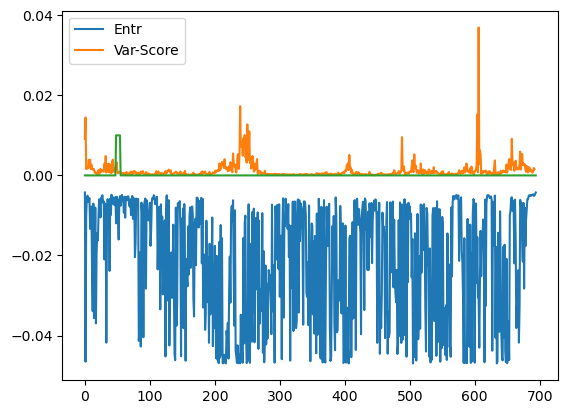

In [26]:
plt.plot(res_entropy_imp-3, label='Entr')
plt.plot(eval_mat[:, :, go_ind].var(axis=1), label='Var-Score')
slim_mask = np.zeros(res_entropy_imp.numpy().shape)
slim_mask[elm_entry.MotifInd] = 1e-2
plt.plot(slim_mask)
plt.legend()
plt.show()

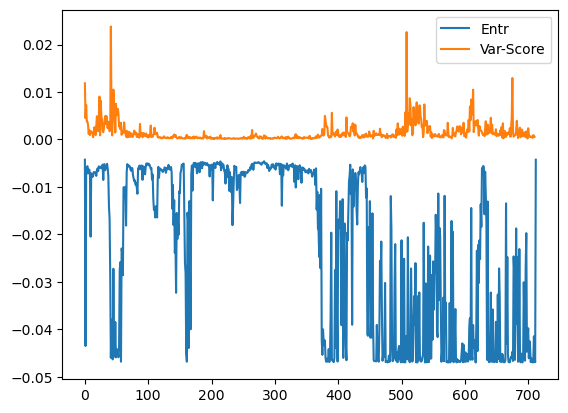

In [23]:
plt.plot(res_entropy_imp-3, label='Entr')
plt.plot(eval_mat[:, :, go_ind].var(axis=1), label='Var-Score')
plt.legend()
plt.show()

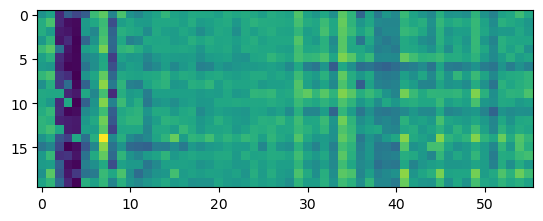

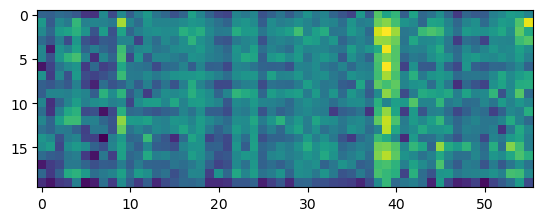

In [ ]:
plt.imshow(eval_mat[500:, :, ].T)
plt.show()
plt.imshow(eval_mat[500:, :, 8].T)
plt.show()

In [30]:
eval_mat.shape

(556, 20, 29185)

4248